In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
MASS = 0.02045833

In [3]:
positions = {}
for label, path in [
    ("NERSC 1", "selected_event_signals_0909.csv"),
    ("NERSC 2", "selected_event_signals_0910.csv"),
]:
    d = pd.read_csv(path)
    d = d[(d["product"] == "pi0") & np.isclose(d["mcp_mass_GeV"], MASS)
          & (d["Distance_cm"] > 20)]
    positions[label] = d[
        [f"cluster{i}_{axis}_cm" for i in (1, 2) for axis in ("x", "y", "z")]
    ].to_numpy().reshape(-1, 2, 3)

d = pd.read_csv("selected.csv")
d = d.groupby("EventID").filter(lambda g: len(g) == 2)
xyz = np.stack([g[["x_cm", "y_cm", "z_cm"]].to_numpy()
                for _, g in d.groupby("EventID")])
positions["Local"] = xyz[np.linalg.norm(xyz[:, 1] - xyz[:, 0], axis=1) > 20]



In [4]:
# Approximate independent cluster-position errors in cm.
# Module-0: sigma_x = 0.6 mm; pixel approximation: sigma_y,z = 1.3 mm.
# https://doi.org/10.3390/instruments8030041, Section 5.3.
sigma_cm = np.array([0.06, 0.13, 0.13])
rng = np.random.default_rng(1234)
angles, angles_smeared, distances_smeared = {}, {}, {}
for label, xyz in positions.items():
    delta = xyz[:, 1] - xyz[:, 0]
    angles[label] = np.arctan2(np.hypot(delta[:, 0], delta[:, 1]),
                              np.abs(delta[:, 2])) * 1e3
    xyz_smeared = xyz + rng.normal(0, sigma_cm, size=xyz.shape)
    delta = xyz_smeared[:, 1] - xyz_smeared[:, 0]
    angles_smeared[label] = np.arctan2(np.hypot(delta[:, 0], delta[:, 1]),
                                      np.abs(delta[:, 2])) * 1e3
    distances_smeared[label] = np.linalg.norm(delta, axis=1)

# Compare the same selected events; this does not recalculate selection efficiency.
angle = np.concatenate(list(angles.values()))
angle_smeared = np.concatenate(list(angles_smeared.values()))

In [12]:
events = pd.concat([
    pd.read_csv("selected_event_signals_0909.csv"),
    pd.read_csv("selected_event_signals_0910.csv"),
], ignore_index=True)
events = events[(events["product"] != "pi0")
                & np.isclose(events["mcp_mass_GeV"], MASS)
                & (events["Distance_cm"] > 20)].copy()

display(events.groupby("product").size().div(20_000_000).rename("acceptance"))


product
dy       1.000000e-06
eta      1.300000e-06
etap     1.250000e-06
jpsi     8.000000e-07
omega    1.300000e-06
phi      1.000000e-06
rho0     1.100000e-06
Name: acceptance, dtype: float64

In [16]:
xyz = events[
    [f"cluster{i}_{a}_cm" for i in (1, 2) for a in ("x", "y", "z")]
].to_numpy(copy=True).reshape(-1, 2, 3)
xyz += np.random.default_rng(1234).normal(0, [0.06, 0.13, 0.13], xyz.shape)
delta = xyz[:, 1] - xyz[:, 0]
events["Theta_z_smeared_rad"] = np.arctan2(
    np.hypot(delta[:, 0], delta[:, 1]), np.abs(delta[:, 2])
)

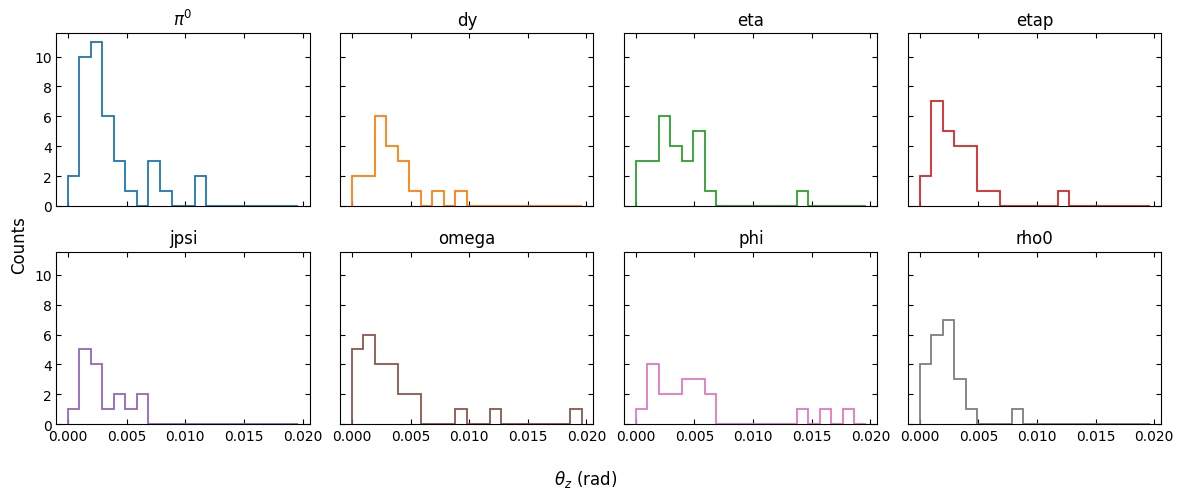

In [22]:
data = [(r"$\pi^0$", angle_smeared / 1000)] + [
    (product, d["Theta_z_smeared_rad"])
    for product, d in events.groupby("product")
]

fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for i, (ax, (product, a)) in enumerate(zip(axes.flat, data)):
    ax.hist(a, bins=bins, histtype="step", color=f"C{i}", linewidth=1.3) 
    ax.set_title(product)
    ax.tick_params(which="both", direction="in", top=True, right=True)

fig.supxlabel(r"$\theta_z$ (rad)")
fig.supylabel("Counts")
plt.tight_layout()
plt.show()

In [23]:
table = pd.read_csv("production_table.csv", index_col=0)
geometry = pd.read_csv("geometry_acceptance.csv").set_index("emitter_pdg")
N_POT = 1.5e19

products = {
    "pi0": (111, r"$\pi^0$"), "dy": (0, "DY"),
    "eta": (221, r"$\eta$"), "etap": (331, r"$\eta'$"),
    "jpsi": (443, r"$J/\psi$"), "omega": (223, r"$\omega$"),
    "phi": (333, r"$\phi$"), "rho0": (113, r"$\rho$")
}


In [24]:
data, weights, normalization = [], [], []

for product, (pdg, label) in products.items():
    a = (np.asarray(angle_smeared) / 1000 if product == "pi0" else
         events.loc[events["product"] == product, "Theta_z_smeared_rad"].to_numpy())
    n_generated = 30_000_000 if product == "pi0" else 20_000_000
    w = (N_POT * table.loc["MCP/POT", label]
         * geometry.loc[pdg, "acceptance_fraction"] / n_generated)
    data.append((label, a))
    weights.append(np.full(a.size, w))
    normalization.append([product, a.size, w, a.size * w])

normalization = pd.DataFrame(normalization, columns=[
    "product", "N_pass", "weight", "N_expected"])
display(normalization)



,product,N_pass,weight,N_expected
0,pi0,39,355.770853,13875.063259
1,dy,20,0.000149,0.002985
2,eta,26,24.567910,638.765652
3,etap,25,0.098219,2.455485
4,jpsi,16,0.000001,0.000022
5,omega,26,0.004122,0.107168
6,phi,20,0.000374,0.007487
7,rho0,22,0.002814,0.061906


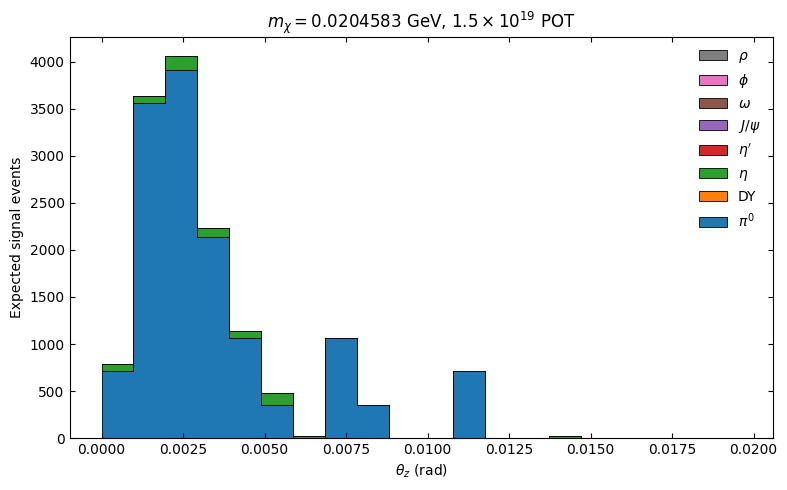

In [25]:
bins = np.linspace(0, max(a.max() for _, a in data if a.size), 21)
plt.figure(figsize=(8, 5))
counts, _, _ = plt.hist(
    [a for _, a in data], bins=bins, weights=weights, stacked=True,
    histtype="stepfilled", color=[f"C{i}" for i in range(8)],
    edgecolor="black", linewidth=0.6, label=[label for label, _ in data])
assert np.isclose(counts[-1].sum(), normalization["N_expected"].sum(),
                  rtol=1e-10, atol=1e-15)

plt.xlabel(r"$\theta_z$ (rad)")
plt.ylabel("Expected signal events")
plt.title(rf"$m_\chi={MASS:g}$ GeV, $1.5\times10^{{19}}$ POT")
plt.legend(frameon=False)
plt.tick_params(which="both", direction="in", top=True, right=True)
plt.tight_layout()
plt.show()